# Integrated Gradients

Getting started with Captum - Titanic Data Analysis

In this notebook, we will demonstrate the basic features of the Captum interpretability library through an example model trained on the Titanic survival data. We will first train a deep neural network on the data using PyTorch and use Captum to understand which of the features were most important and how the network reached its prediction.

Note: Before running this tutorial, please install the scipy, pandas, and matplotlib packages.

In [1]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 8.9 MB/s eta 0:00:00


In [2]:
!pip install scipy pandas matplotlib

In [3]:
# Initial imports
import os
import requests
import numpy as np

import torch

from captum.attr import IntegratedGradients
from captum.attr import LayerConductance
from captum.attr import Lime
from captum.attr import NeuronConductance

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from scipy import stats
import pandas as pd

We will begin by importing and cleaning the dataset. The code cell below will automatically download the titanic3.csv dataset from https://hbiostat.org/data/repo/titanic3.csv and save it to the tutorials/data/ folder if it is not already present.

In [4]:
import os
import pandas as pd
import requests

dataset_path = 'data/titanic3.csv'
url = 'https://hbiostat.org/data/repo/titanic3.csv'

# 1. Δημιουργία του φακέλου 'data' αν δεν υπάρχει
os.makedirs('data', exist_ok=True)

# 2. Λήψη του αρχείου αν δεν έχει ήδη κατέβει
if not os.path.exists(dataset_path):
  print(f'Downloading {url} to {dataset_path}...')
  headers = {'User-Agent': 'Mozilla/5.0'}
  response = requests.get(url, headers=headers)
  with open(dataset_path, 'wb') as f:
    f.write(response.content)
  print('Download complete.')

# 3. Φόρτωση στο pandas DataFrame
titanic_data = pd.read_csv(dataset_path)
print('Dataset shape:', titanic_data.shape)
titanic_data.head(3)

Download complete.
Dataset shape: (1309, 14)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


With the data loaded, we now preprocess the data by converting some categorical features such as gender, location of embarkation, and passenger class into one-hot encodings (separate feature columns for each class with 0 / 1). We also remove some features that are more difficult to analyze, such as name, and fill missing values in age and fare with the average values.

In [5]:
titanic_data = pd.concat([titanic_data,
                          pd.get_dummies(titanic_data['sex']),
                          pd.get_dummies(titanic_data['embarked'],prefix="embark"),
                          pd.get_dummies(titanic_data['pclass'],prefix="class")], axis=1)
titanic_data["age"] = titanic_data["age"].fillna(titanic_data["age"].mean())
titanic_data["fare"] = titanic_data["fare"].fillna(titanic_data["fare"].mean())
titanic_data = titanic_data.drop(['name','ticket','cabin','boat','body','home.dest','sex','embarked','pclass'], axis=1)

After processing, the features we have are:

* Age - Passenger Age
* Sibsp - Number of Siblings / Spouses Aboard
* Parch - Number of Parents / Children Aboard
* Fare - Fare Amount Paid in British Pounds
* Female - Binary variable indicating whether passenger is female
* Male - Binary variable indicating whether passenger is male
* EmbarkC - Binary variable indicating whether passenger embarked at Cherbourg
* EmbarkQ - Binary variable indicating whether passenger embarked at Queenstown
* EmbarkS - Binary variable indicating whether passenger embarked at Southampton
* Class1 - Binary variable indicating whether passenger was in first class
* Class2 - Binary variable indicating whether passenger was in second class
Class3 - Binary variable indicating whether passenger was in third class
(Reference: http://campus.lakeforest.edu/frank/FILES/MLFfiles/Bio150/Titanic/TitanicMETA.pdf)

We now convert the data to numpy arrays and separate the training and test sets.

In [6]:
# Set random seed for reproducibility.
np.random.seed(131254)

# Convert features and labels to numpy arrays.
labels = titanic_data["survived"].to_numpy()
titanic_data = titanic_data.drop(['survived'], axis=1)
feature_names = list(titanic_data.columns)
data = titanic_data.to_numpy()

# Separate training and test sets using
train_indices = np.random.choice(len(labels), int(0.7*len(labels)), replace=False)
test_indices = list(set(range(len(labels))) - set(train_indices))
train_features = np.array(data[train_indices], dtype=float)
train_labels = labels[train_indices]
test_features = np.array(data[test_indices], dtype=float)
test_labels = labels[test_indices]

We are now ready to define the neural network architecture we will use for the task. We have defined a simple architecture using 2 hidden layers, the first with 12 hidden units and the second with 8 hidden units, each with Sigmoid non-linearity. The final layer has 2 output units, corresponding to the logits for either survived (1) or not survived (0).

In [7]:
import torch
import torch.nn as nn
torch.manual_seed(1)  # Set seed for reproducibility.
class TitanicSimpleNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(12, 12)
        self.sigmoid1 = nn.Sigmoid()
        self.linear2 = nn.Linear(12, 8)
        self.sigmoid2 = nn.Sigmoid()
        self.linear3 = nn.Linear(8, 2)

    def forward(self, x):
        lin1_out = self.linear1(x)
        sigmoid_out1 = self.sigmoid1(lin1_out)
        sigmoid_out2 = self.sigmoid2(self.linear2(sigmoid_out1))
        return self.linear3(sigmoid_out2)

We can either use a pretrained model or train the network using the training data for 200 epochs. Note that the results of later steps may not match if retraining. The pretrained model can be downloaded here: https://github.com/pytorch/captum/blob/master/tutorials/models/titanic_model.pt

In [9]:
import os
import urllib.request
import torch
import torch.nn as nn

# 1. Create directory for models if it doesn't already exist
os.makedirs('models', exist_ok=True)

# 2. Download the official pretrained model weights from the Captum repository
url = 'https://raw.githubusercontent.com/pytorch/captum/master/tutorials/models/titanic_model.pt'
model_path = 'models/titanic_model.pt'

if not os.path.exists(model_path):
    print("Downloading official pretrained model...")
    urllib.request.urlretrieve(url, model_path)
    print("Download complete!")

# 3. Instantiate model architecture and load pretrained weights
net = TitanicSimpleNNModel()
USE_PRETRAINED_MODEL = True

if USE_PRETRAINED_MODEL:
    net.load_state_dict(torch.load(model_path, weights_only=True))
    net.eval()  # Set model to evaluation mode
    print("Pretrained model loaded successfully!")

    # Prepare input and label tensors for evaluation
    input_tensor = torch.from_numpy(train_features).type(torch.FloatTensor)
    label_tensor = torch.from_numpy(train_labels)
else:
    # Optional training routine fallback if USE_PRETRAINED_MODEL is False
    criterion = nn.CrossEntropyLoss()
    num_epochs = 200
    optimizer = torch.optim.Adam(net.parameters(), lr=0.1)

    input_tensor = torch.from_numpy(train_features).type(torch.FloatTensor)
    label_tensor = torch.from_numpy(train_labels)

    for epoch in range(num_epochs):
        output = net(input_tensor)
        loss = criterion(output, label_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if epoch % 20 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} => Loss: {loss.item():.2f}")

    # Save newly trained model weights
    torch.save(net.state_dict(), model_path)
    print("Trained model saved successfully!")

Download complete!
Pretrained model loaded successfully!


We can now evaluate the training and test accuracies of our model.

In [10]:
out_logits = net(input_tensor).detach().numpy()
out_classes = np.argmax(out_logits, axis=1)
print("Train Accuracy:", sum(out_classes == train_labels) / len(train_labels))

Train Accuracy: 0.8493449781659389


In [11]:
test_input_tensor = torch.from_numpy(test_features).type(torch.FloatTensor)
out_logits = net(test_input_tensor).detach().numpy()
out_classes = np.argmax(out_logits, axis=1)
print("Test Accuracy:", sum(out_classes == test_labels) / len(test_labels))

Test Accuracy: 0.816793893129771


Beyond just considering the accuracy of the classifier, there are many important questions to understand how the model is working and its decision, which is the purpose of Captum, to help make neural networks in PyTorch more interpretable.

The first question we can ask is which of the features were actually important to the model to reach this decision? This is the first main component of Captum, the ability to obtain Feature Attributions. For this example, we will apply Integrated Gradients, which is one of the Feature Attribution methods included in Captum. More information regarding Integrated Gradients can be found in the original paper here: https://arxiv.org/pdf/1703.01365.pdf.

To apply Integrated Gradients, we first create an IntegratedGradients object, providing the model object.

In [12]:
ig = IntegratedGradients(net)

To compute the Integrated Gradients, we use the attribute method of the IntegratedGradients object. The method takes tensor(s) of input examples (matching the forward function of the model), and returns the input attributions for the given examples. For a network with multiple outputs, a target index must also be provided, defining the index of the output for which gradients are computed. For this example, we provide target=1, corresponding to survival.

The input tensor provided should require grad, so we call requires_grad_ on the tensor. The attribute method also takes a baseline, which is the starting point from which gradients are integrated. The default value is just the 0 tensor, which is a reasonable baseline / default for this task.

The returned values of the attribute method are the attributions, which match the size of the given inputs, and delta, which approximates the error between the approximated integral and true integral.

In [13]:
test_input_tensor.requires_grad_()
attr, delta = ig.attribute(test_input_tensor,target=1, return_convergence_delta=True)
attr = attr.detach().numpy()

To understand these attributions, we can first average them across all the inputs and print / visualize the average attribution for each feature.

Average Feature Importances
age :  -5.753
sibsp :  -1.318
parch :  -0.308
fare :  3.059
female :  1.843
male :  -3.192
embark_C :  0.776
embark_Q :  -0.010
embark_S :  -0.790
class_1 :  0.584
class_2 :  0.221
class_3 :  -1.346


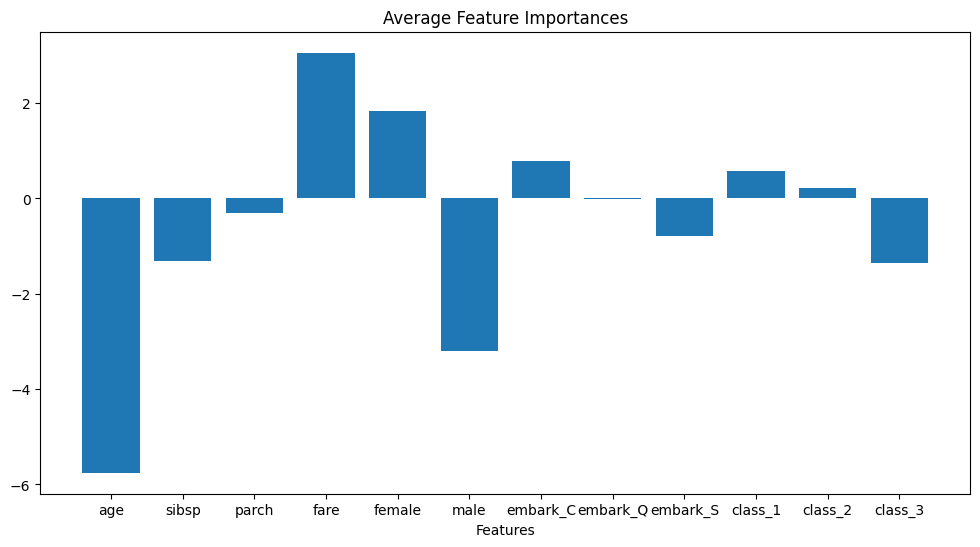

In [14]:
# Helper method to print importances and visualize distribution
def visualize_importances(feature_names, importances, title="Average Feature Importances", plot=True, axis_title="Features"):
    print(title)
    for i in range(len(feature_names)):
        print(feature_names[i], ": ", '%.3f'%(importances[i]))
    x_pos = (np.arange(len(feature_names)))
    if plot:
        plt.figure(figsize=(12,6))
        plt.bar(x_pos, importances, align='center')
        plt.xticks(x_pos, feature_names, wrap=True)
        plt.xlabel(axis_title)
        plt.title(title)
visualize_importances(feature_names, np.mean(attr, axis=0))

From the feature attribution information, we obtain some interesting insights regarding the importance of various features. We see that the strongest features appear to be age and being male, which are negatively correlated with survival. Embarking at Queenstown and the number of parents / children appear to be less important features generally.

An important thing to note is that the average attributions over the test set don't necessarilly capture all the information regarding feature importances. We should also look at the distribution of attributions for each feature. It is possible that features have very different attributions for different examples in the dataset.

For instance, we can visualize the distribution of attributions for sibsp, the number of siblings / spouses.

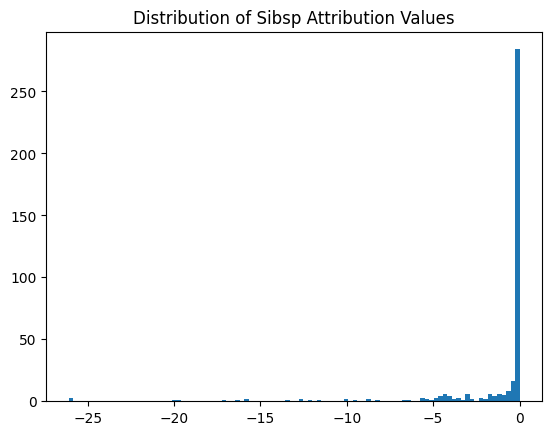

In [15]:
plt.hist(attr[:,1], 100);
plt.title("Distribution of Sibsp Attribution Values");

We note that a vast majority of the examples have an attribution value of 0 for sibsp, which likely corresponds to having a value of 0 for the feature (IntegratedGradients would provide an attribution of 0 when the feature value matches the baseline of 0). More significantly, we see that although the average seems smaller in magnitude in the plot above, there are a small number of examples with extremely negative attributions for this feature.

To better understand this, we can bucket the examples by the value of the sibsp feature and plot the average attribution for the feature. In the plot below, the size of the dot is proportional to the number of examples with that value.

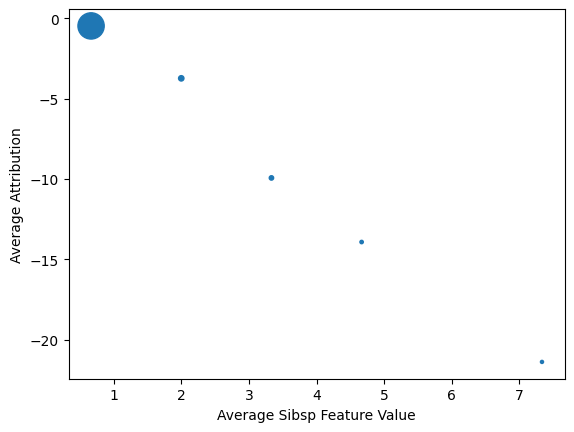

In [16]:
bin_means, bin_edges, _ = stats.binned_statistic(test_features[:,1], attr[:,1], statistic='mean', bins=6)
bin_count, _, _ = stats.binned_statistic(test_features[:,1], attr[:,1], statistic='count', bins=6)

bin_width = (bin_edges[1] - bin_edges[0])
bin_centers = bin_edges[1:] - bin_width/2
plt.scatter(bin_centers, bin_means, s=bin_count)
plt.xlabel("Average Sibsp Feature Value");
plt.ylabel("Average Attribution");

We see that the larger magnitude attributions correspond to the examples with larger Sibsp feature values, suggesting that the feature has a larger impact on prediction for these examples. Since there are substantially fewer of these examples (compared to those with a feature value of 0), the average attribution does not completely capture this effect.